# BD II - Polymarket no BigQuery

Trainee: Sylvio Helt


O evento escolhido foi o mercado “TikTok banned in the US before May 2025?”, identificado pelo market_id = 507276 no conjunto de dados do Polymarket.

O mercado foi criado em 17 de setembro de 2024, possuía data de encerramento prevista para 30 de abril de 2025 e apresentava volume acumulado informado de aproximadamente US$ 119,7 milhões. Os registros de negociação disponíveis, no entanto, vão de 18 de setembro de 2024 a 21 de janeiro de 2025.

A análise investiga como o volume negociado e a probabilidade implícita do resultado Yes se comportaram ao longo desse período, especialmente em momentos próximos a acontecimentos relacionados à possível proibição do TikTok nos Estados Unidos.

A hipótese inicial é que a divulgação de informações relevantes esteja temporalmente associada ao aumento da atividade de negociação e a mudanças mais intensas na probabilidade atribuída pelos participantes. A análise busca observar essas relações temporais sem assumir uma relação direta de causalidade.

## 2. Exploração Inicial

### 2.1 Seleção e caracterização inicial do mercado

A exploração foi iniciada pela identificação de mercados encerrados com elevado volume negociado. A consulta aos mercados de maior volume permite selecionar um caso com quantidade suficiente de negociações para análise temporal e cujo desfecho já seja conhecido.


```sql
SELECT
    market_id,
    question,
    event_title,
    volume,
    created_at,
    end_date,
    closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE closed = TRUE
ORDER BY volume DESC
LIMIT 50;
```

In [1]:
import pandas as pd

mercados = pd.read_csv(
    "dados/01_mercados_fechados_maior_volume.csv"
)

mercados.head()

,market_id,question,event_title,volume,created_at,end_date,closed
0,253591,Will Donald Trump win the 2024 US Presidential...,Presidential Election Winner 2024,1.531479e+09,2024-01-04 17:33:51.000000 UTC,2024-11-05 12:00:00.000000 UTC,1
1,253597,Will Kamala Harris win the 2024 US Presidentia...,Presidential Election Winner 2024,1.037039e+09,2024-01-04 17:40:17.000000 UTC,2024-11-04 12:00:00.000000 UTC,1
2,511754,Will Donald Trump be inaugurated?,Who will be inaugurated as President?,4.004095e+08,2024-11-01 20:59:58.000000 UTC,2025-01-20 12:00:00.000000 UTC,1
3,507892,Will the Sacramento Kings win the 2025 NBA Fin...,NBA Champion,3.780115e+08,2024-09-24 15:33:30.000000 UTC,2025-06-23 12:00:00.000000 UTC,1
4,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,(Old) Romania Election,3.265077e+08,2024-11-07 23:53:29.000000 UTC,2024-12-08 12:00:00.000000 UTC,1


In [2]:
mercado_selecionado = mercados[
    mercados["market_id"].astype(str) == "507276"
]

mercado_selecionado

,market_id,question,event_title,volume,created_at,end_date,closed
30,507276,TikTok banned in the US before May 2025?,TikTok banned in the US before May 2025?,1.196534e+08,2024-09-17 14:54:44.000000 UTC,2025-04-30 12:00:00.000000 UTC,1


Entre os mercados encontrados, foi selecionado “TikTok banned in the US before May 2025?”, identificado pelo market_id = 507276. O mercado registrou aproximadamente US$ 119,7 milhões em volume total e apresenta um período suficientemente extenso de negociação para investigar alterações.

Além do elevado volume, o mercado foi escolhido por estar associado a um evento externo bem delimitado, permitindo posteriormente comparar períodos de comportamento atípico encontrados nos dados com acontecimentos conhecidos.

### 2.2 Período efetivo e dimensão das negociações

Após a seleção do mercado, foram consultados diretamente os registros de negociação para identificar o período efetivo de atividade.


```sql
SELECT
    MIN(trade_timestamp) AS primeira_negociacao,
    MAX(trade_timestamp) AS ultima_negociacao,
    COUNT(*) AS total_trades,
    SUM(usd_amount) AS volume_total_usd
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE
    market_id = '507276'
    AND DATE(trade_timestamp) BETWEEN '2024-09-17' AND '2025-04-30';
```

In [3]:
periodo_mercado = pd.read_csv(
    "dados/02_periodo_efetivo_mercado.csv"
)

periodo_mercado

,primeira_negociacao,ultima_negociacao,total_trades,volume_total_usd
0,2024-09-18 01:03:02.000000 UTC,2025-01-21 17:34:37.000000 UTC,62286,70343464.41


A consulta mostrou que o mercado registrou negociações entre 18 de setembro de 2024 e 21 de janeiro de 2025, totalizando 62.286 operações e aproximadamente US$ 70,34 milhões em volume negociado. Como o evento central ocorreu em 19 de janeiro, os últimos dias da série são os mais relevantes para a análise das mudanças de volume e preço.

### 2.3 Exploração temporal de volume e preço

Em seguida, as negociações foram visualizadas por dia para observar a evolução do volume, da quantidade de operações e do preço ao longo de todo o período de atividade do mercado. Essa visão inicial permite identificar concentrações de negociação e períodos de maior variação antes de aprofundar a análise em janelas temporais menores.


```sql
SELECT
    trade_date,
    daily_trade_count,
    daily_usd_volume,
    avg_trade_price,
    min_trade_price,
    max_trade_price,
    rolling_7d_avg_volume
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE
    market_id = '507276'
    AND trade_date BETWEEN '2024-09-18' AND '2025-01-21'
ORDER BY trade_date;
```

In [4]:
serie_diaria = pd.read_csv(
    "dados/03_serie_diaria_tiktok.csv"
)

serie_diaria["trade_date"] = pd.to_datetime(
    serie_diaria["trade_date"]
)

serie_diaria.head(10)

,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price,rolling_7d_avg_volume
0,2024-09-18,47,1850.00,0.588508,0.23,0.75,1850.000000
1,2024-09-19,37,786.18,0.247568,0.22,0.29,1318.090000
2,2024-09-20,13,148.40,0.203846,0.20,0.21,928.193333
3,2024-09-21,14,126.11,0.549285,0.14,0.85,727.672500
4,2024-09-22,1,4.88,0.830000,0.83,0.83,583.114000
5,2024-09-23,9,535.77,0.530000,0.15,0.85,575.223333
6,2024-09-24,11,8.25,0.217273,0.15,0.83,494.227143
7,2024-09-25,5,32.57,0.830000,0.83,0.83,234.594286
8,2024-09-26,3,1.20,0.603333,0.15,0.83,122.454286
9,2024-09-27,12,262.75,0.378333,0.15,0.83,138.790000


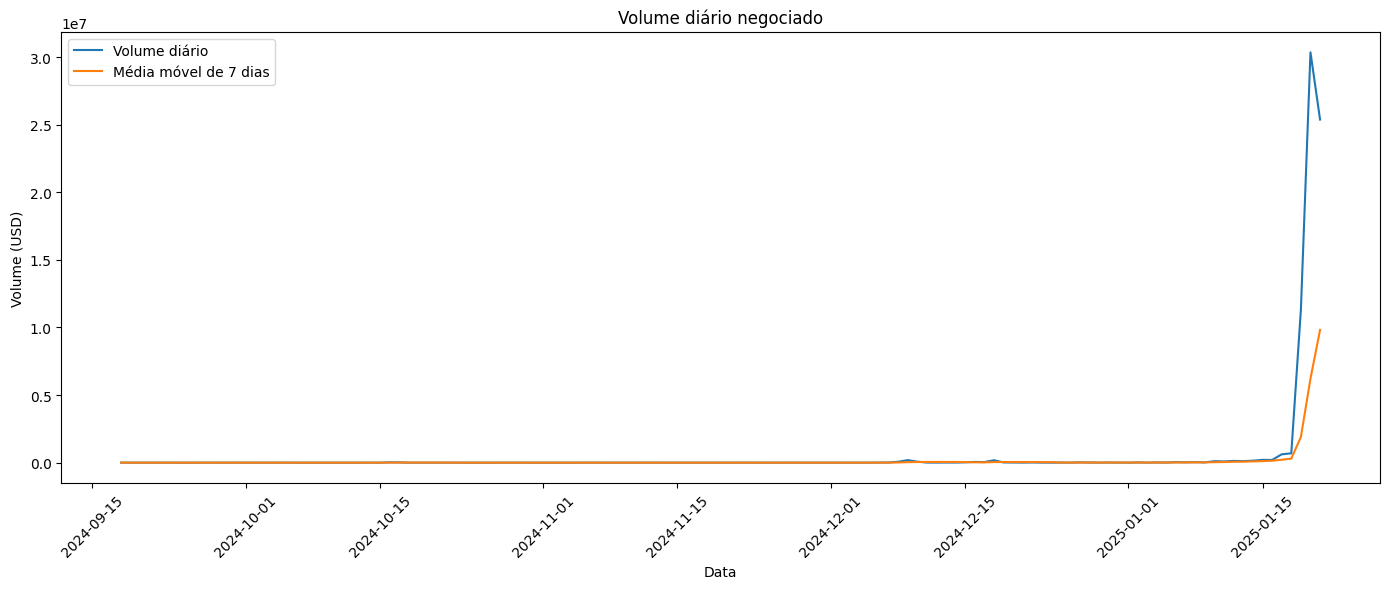

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    serie_diaria["trade_date"],
    serie_diaria["daily_usd_volume"],
    label="Volume diário"
)

plt.plot(
    serie_diaria["trade_date"],
    serie_diaria["rolling_7d_avg_volume"],
    label="Média móvel de 7 dias"
)

plt.title("Volume diário negociado")
plt.xlabel("Data")
plt.ylabel("Volume (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

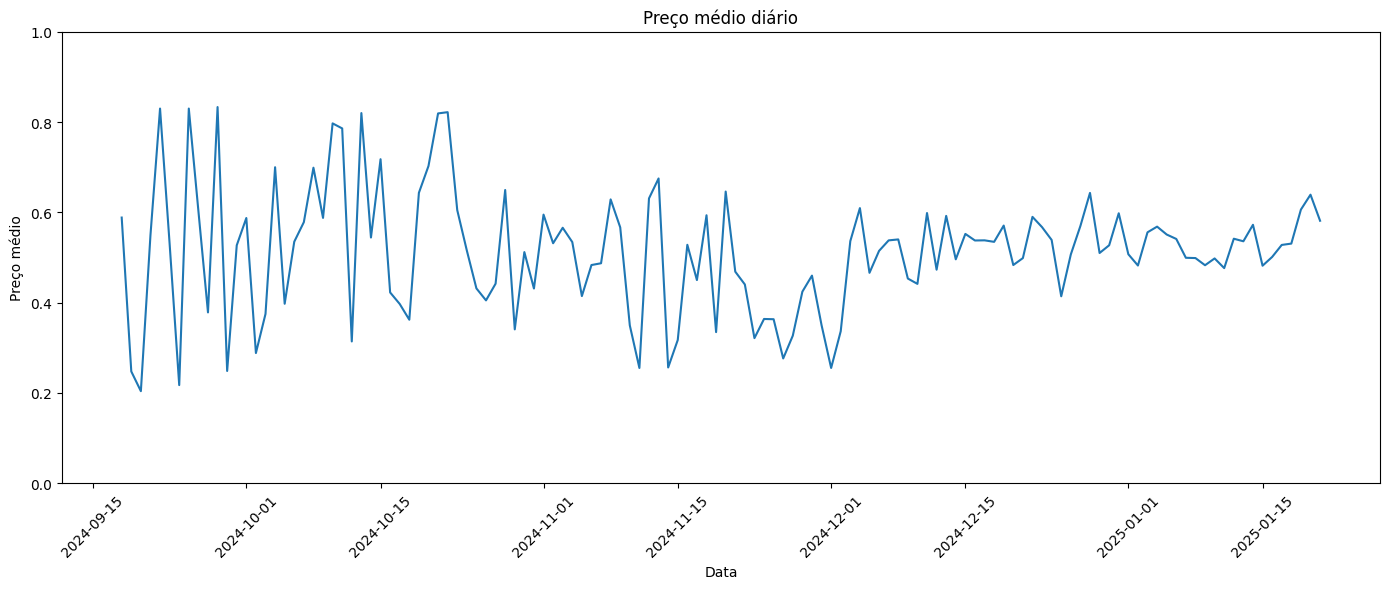

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_diaria["trade_date"],
    serie_diaria["avg_trade_price"]
)

plt.title("Preço médio diário")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

A série diária mostra que o mercado apresentou baixo volume durante grande parte do período, seguido por aumento progressivo da atividade a partir de dezembro e forte concentração de negociações nos dias finais.

Os maiores volumes ocorreram em 19, 20 e 21 de janeiro de 2025, com destaque para 20 de janeiro, que registrou aproximadamente US$ 30,35 milhões negociados. O número de operações também atingiu seu máximo em 19 de janeiro, com 10.678 trades.

A evolução do preço médio diário também apresenta alterações nos últimos dias, indicando que o período próximo ao evento central concentra simultaneamente maior atividade e mudanças relevantes na avaliação do mercado.

### 2.4 Exploração horária do período crítico

A exploração diária mostrou forte concentração de volume e número de negociações entre 17 e 21 de janeiro de 2025. Para investigar com maior detalhe esse intervalo, as negociações foram agregadas por hora, permitindo observar a dinâmica de volume e preço ao longo dos dias próximos ao evento central.

```sql
SELECT
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,
    COUNT(*) AS trade_count,
    SUM(usd_amount) AS usd_volume,
    AVG(price) AS avg_price,
    MIN(price) AS min_price,
    MAX(price) AS max_price
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE
    market_id = '507276'
    AND DATE(trade_timestamp) BETWEEN '2025-01-17' AND '2025-01-21'
GROUP BY trade_hour
ORDER BY trade_hour;
```

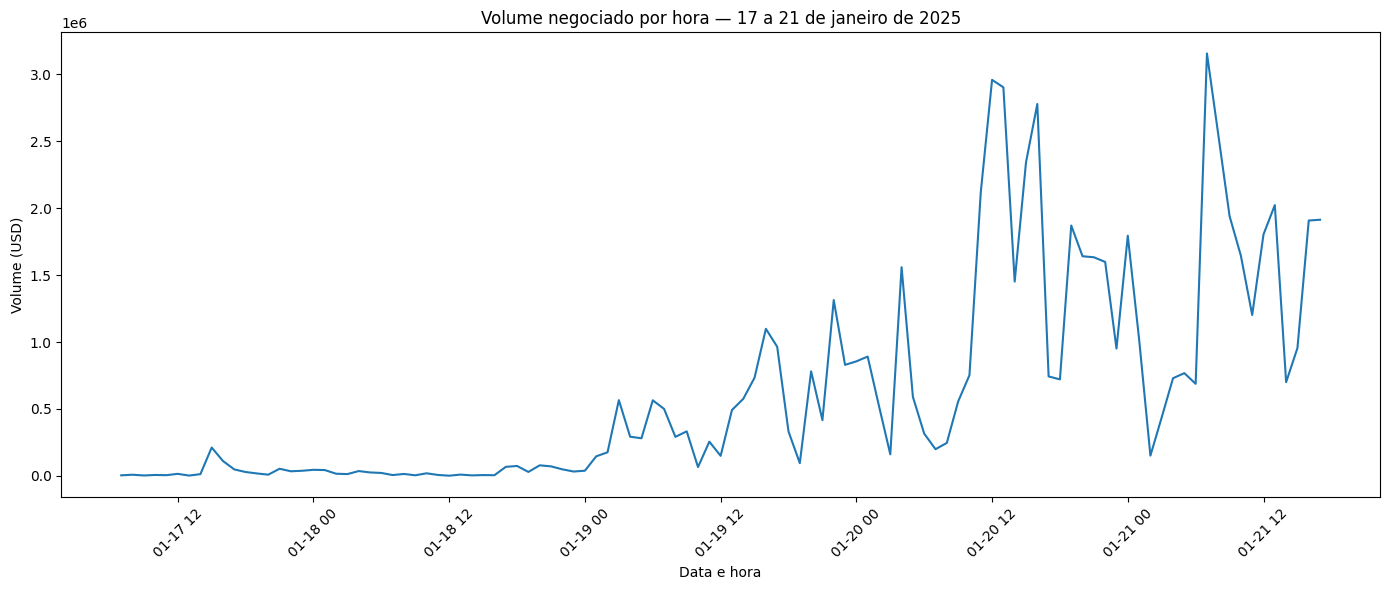

In [7]:
serie_horaria = pd.read_csv(
    "dados/04_serie_horaria_periodo_critico.csv"
)

serie_horaria["trade_hour"] = pd.to_datetime(
    serie_horaria["trade_hour"]
)

plt.figure(figsize=(14, 6))

plt.plot(
    serie_horaria["trade_hour"],
    serie_horaria["usd_volume"]
)

plt.title("Volume negociado por hora — 17 a 21 de janeiro de 2025")
plt.xlabel("Data e hora")
plt.ylabel("Volume (USD)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

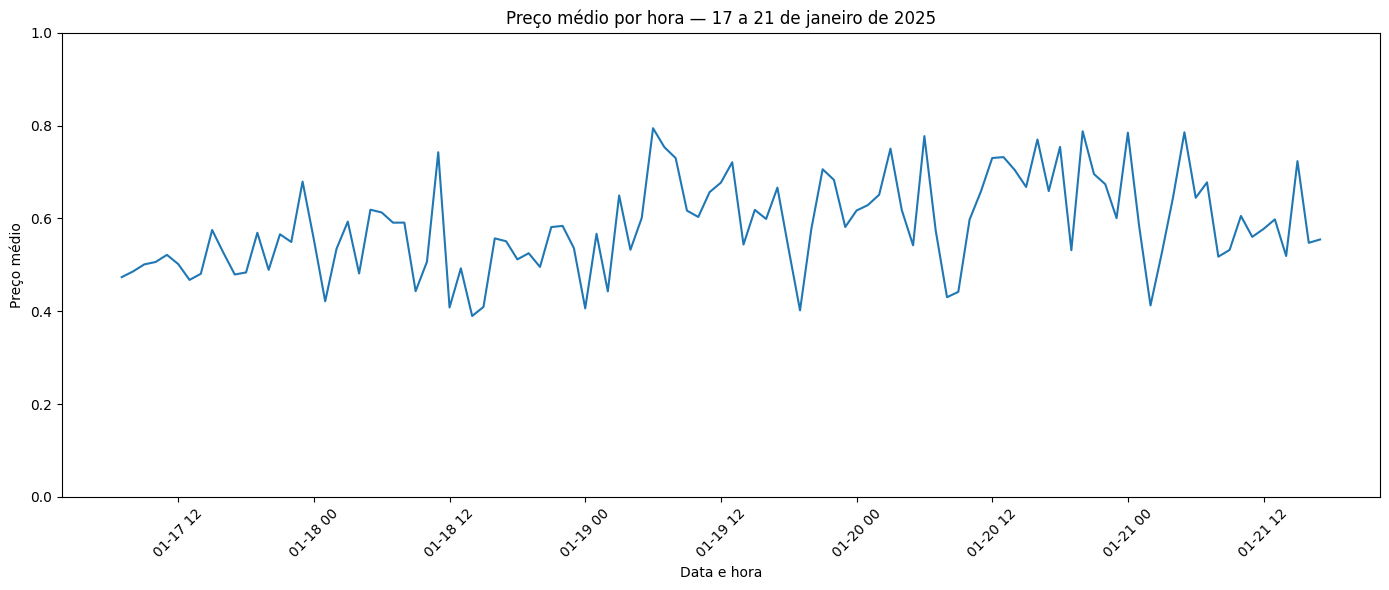

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_horaria["trade_hour"],
    serie_horaria["avg_price"]
)

plt.title("Preço médio por hora — 17 a 21 de janeiro de 2025")
plt.xlabel("Data e hora")
plt.ylabel("Preço médio")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

A análise horária confirmou que a concentração observada na série diária também ocorre dentro dos próprios dias. Os maiores volumes horários aparecem principalmente em 20 e 21 de janeiro, chegando a aproximadamente US$ 3,15 milhões em uma única hora.

O preço médio também apresenta oscilações relevantes nesse intervalo, enquanto diversas horas registram ampla diferença entre os preços mínimo e máximo. Isso indica que a agregação diária pode ocultar movimentos internos importantes e justifica considerar uma granularidade horária nas análises posteriores de comportamento atípico.

## 3. Agregações e construção dos indicadores

### 3.1 Série horária contínua e comportamento do volume

A exploração inicial mostrou que a atividade do mercado varia significativamente ao longo do tempo e que existem períodos sem negociações. Para analisar corretamente o volume em janelas móveis, foi construída uma série horária contínua entre a primeira e a última data de negociação. As horas sem operações são representadas com volume e número de trades iguais a zero.

Sobre essa série são calculadas a média e o desvio padrão do volume das 24 horas anteriores. Em seguida, o Z-score mede quanto o volume de cada hora se afasta desse comportamento recente. A hora atual é excluída da janela de referência, evitando que um eventual pico influencie sua própria comparação.


```sql
WITH horas AS (
    SELECT
        trade_hour
    FROM UNNEST(
        GENERATE_TIMESTAMP_ARRAY(
            TIMESTAMP('2024-09-18 01:00:00+00'),
            TIMESTAMP('2025-01-21 17:00:00+00'),
            INTERVAL 1 HOUR
        )
    ) AS trade_hour
),

volume_por_hora AS (
    SELECT
        TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,
        COUNT(*) AS trade_count,
        SUM(usd_amount) AS usd_volume
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE
        market_id = '507276'
        AND DATE(trade_timestamp) BETWEEN '2024-09-18' AND '2025-01-21'
    GROUP BY
        trade_hour
),

serie_horaria AS (
    SELECT
        h.trade_hour,
        COALESCE(v.trade_count, 0) AS trade_count,
        COALESCE(v.usd_volume, 0) AS usd_volume
    FROM horas AS h
    LEFT JOIN volume_por_hora AS v
        ON h.trade_hour = v.trade_hour
),

estatisticas_volume AS (
    SELECT
        trade_hour,
        trade_count,
        usd_volume,

        COUNT(*) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS horas_historico,

        AVG(usd_volume) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS avg_volume_24h,

        STDDEV_SAMP(usd_volume) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS stddev_volume_24h

    FROM serie_horaria
)

SELECT
    trade_hour,
    trade_count,
    usd_volume,
    avg_volume_24h,
    stddev_volume_24h,

    CASE
        WHEN horas_historico = 24
             AND stddev_volume_24h > 0
        THEN SAFE_DIVIDE(
            usd_volume - avg_volume_24h,
            stddev_volume_24h
        )
    END AS z_score_volume

FROM estatisticas_volume
ORDER BY
    trade_hour;
```

Apesar de ser construída uma série horária contínua, a tabela transacional é acessada apenas uma vez e somente para o mercado e o intervalo de datas analisados. O filtro por `market_id` aproveita a organização da tabela por mercado, enquanto a restrição explícita sobre `trade_timestamp` limita a leitura das partições necessárias. Além disso, os trades são agregados por hora antes da aplicação das funções de janela, reduzindo significativamente a quantidade de registros processados nas etapas seguintes.


In [9]:
volume_horario = pd.read_csv(
    "dados/05_volume_horario_continuo.csv"
)

volume_horario["trade_hour"] = pd.to_datetime(
    volume_horario["trade_hour"]
)

volume_horario.head()

,trade_hour,trade_count,usd_volume,avg_volume_24h,stddev_volume_24h,z_score_volume
0,2024-09-18 01:00:00+00:00,2,39.72,NaN,NaN,NaN
1,2024-09-18 02:00:00+00:00,2,11.65,39.720,NaN,NaN
2,2024-09-18 03:00:00+00:00,1,0.08,25.685,19.848487,NaN
3,2024-09-18 04:00:00+00:00,4,566.25,17.150,20.384305,NaN
4,2024-09-18 05:00:00+00:00,0,0.00,154.425,275.054023,NaN


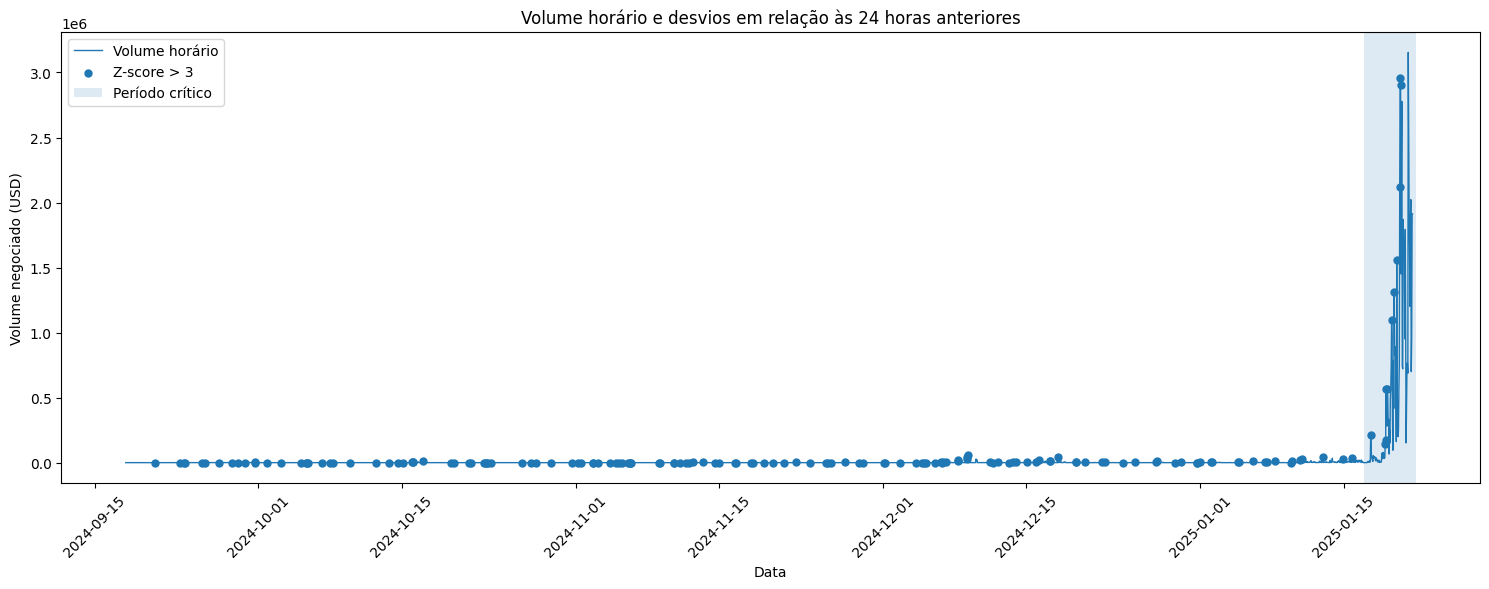

In [10]:
volume_atipico = volume_horario[
    volume_horario["z_score_volume"] > 3
]
plt.figure(figsize=(15, 6))

plt.plot(
    volume_horario["trade_hour"],
    volume_horario["usd_volume"],
    linewidth=1,
    label="Volume horário"
)

plt.scatter(
    volume_atipico["trade_hour"],
    volume_atipico["usd_volume"],
    s=25,
    label="Z-score > 3",
    zorder=3
)

plt.axvspan(
    pd.Timestamp("2025-01-17", tz="UTC"),
    pd.Timestamp("2025-01-21 23:59:59", tz="UTC"),
    alpha=0.15,
    label="Período crítico"
)

plt.title("Volume horário e desvios em relação às 24 horas anteriores")
plt.xlabel("Data")
plt.ylabel("Volume negociado (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

O Z-score permite identificar horas em que o volume se distancia do comportamento das 24 horas anteriores. Entretanto, valores elevados também podem ocorrer após períodos de baixa atividade, mesmo quando o volume absoluto é pequeno.

Assim, o Z-score será utilizado como indicador de excepcionalidade, enquanto o alerta final deverá combiná-lo com uma medida de magnitude do volume para reduzir sinais pouco relevantes.


### 3.2 Comportamento do preço e da probabilidade

A segunda análise busca identificar movimentações atípicas na probabilidade implícita do mercado. Antes de construir a série temporal de preços, é necessário identificar os ativos negociados e determinar qual deles corresponde ao resultado `Yes`, evitando combinar preços de resultados distintos em uma mesma média.


```sql
SELECT
    asset_id,
    nonusdc_side,
    COUNT(*) AS total_trades,
    MIN(price) AS min_price,
    MAX(price) AS max_price,
    AVG(price) AS avg_price
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE
    market_id = '507276'
    AND DATE(trade_timestamp) BETWEEN '2024-09-18' AND '2025-01-21'
GROUP BY
    asset_id,
    nonusdc_side
ORDER BY
    total_trades DESC;
```

### 3.2 Comportamento do preço e da probabilidade

Para analisar a probabilidade implícita do mercado, foi utilizado exclusivamente o token correspondente ao resultado **Yes**. O último preço negociado em cada hora foi adotado como referência do estado do mercado naquele período. Nas horas sem negociação do token, o último preço disponível é mantido.

A partir dessa série contínua, calcula-se a variação absoluta de preço entre horas consecutivas e seu Z-score em relação às 24 horas anteriores, permitindo identificar movimentações de preço excepcionalmente intensas.


```sql
WITH horas AS (
    SELECT
        trade_hour
    FROM UNNEST(
        GENERATE_TIMESTAMP_ARRAY(
            TIMESTAMP('2024-09-18 01:00:00+00'),
            TIMESTAMP('2025-01-21 17:00:00+00'),
            INTERVAL 1 HOUR
        )
    ) AS trade_hour
),

preco_por_hora AS (
    SELECT
        TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,

        ARRAY_AGG(
            price
            ORDER BY trade_timestamp DESC
            LIMIT 1
        )[OFFSET(0)] AS close_price

    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE
        market_id = '507276'
        AND asset_id =
            '24635636911615866092589652362670811323984202357282728474473612545495782013438'
        AND DATE(trade_timestamp) BETWEEN '2024-09-18' AND '2025-01-21'
    GROUP BY
        trade_hour
),

serie_preco AS (
    SELECT
        h.trade_hour,

        LAST_VALUE(
            p.close_price IGNORE NULLS
        ) OVER (
            ORDER BY h.trade_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS yes_price

    FROM horas AS h
    LEFT JOIN preco_por_hora AS p
        ON h.trade_hour = p.trade_hour
),

variacoes AS (
    SELECT
        trade_hour,
        yes_price,
        LAG(yes_price) OVER (
            ORDER BY trade_hour
        ) AS previous_price

    FROM serie_preco
),

variacoes_calculadas AS (
    SELECT
        trade_hour,
        yes_price,
        previous_price,
        ABS(yes_price - previous_price) AS price_change
    FROM variacoes
),

estatisticas_preco AS (
    SELECT
        trade_hour,
        yes_price,
        previous_price,
        price_change,

        COUNT(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS horas_historico,

        AVG(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS avg_change_24h,

        STDDEV_SAMP(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS stddev_change_24h

    FROM variacoes_calculadas
)

SELECT
    trade_hour,
    yes_price,
    previous_price,
    price_change,
    avg_change_24h,
    stddev_change_24h,

    CASE
        WHEN horas_historico = 24
             AND stddev_change_24h > 0
        THEN SAFE_DIVIDE(
            price_change - avg_change_24h,
            stddev_change_24h
        )
    END AS z_score_price

FROM estatisticas_preco
ORDER BY
    trade_hour;
```

A consulta permitiu distinguir os dois ativos negociados no mercado. O token correspondente ao resultado Yes foi identificado pelo asset_id:

24635636911615866092589652362670811323984202357282728474473612545495782013438

Esse ativo foi utilizado isoladamente nas consultas seguintes, evitando a combinação entre os preços dos resultados Yes e No.

In [11]:
preco_horario = pd.read_csv(
    "dados/06_yes.csv"
)

preco_horario["trade_hour"] = pd.to_datetime(
    preco_horario["trade_hour"]
)

preco_horario.head()

,trade_hour,yes_price,previous_price,price_change,avg_change_24h,stddev_change_24h,z_score_price
0,2024-09-18 01:00:00+00:00,0.240000,NaN,NaN,NaN,NaN,NaN
1,2024-09-18 02:00:00+00:00,0.230000,0.240000,0.010000,NaN,NaN,NaN
2,2024-09-18 03:00:00+00:00,0.240001,0.230000,0.010001,0.010000,NaN,NaN
3,2024-09-18 04:00:00+00:00,0.240001,0.240001,0.000000,0.010000,7.071068e-07,NaN
4,2024-09-18 05:00:00+00:00,0.240001,0.240001,0.000000,0.006667,5.773791e-03,NaN


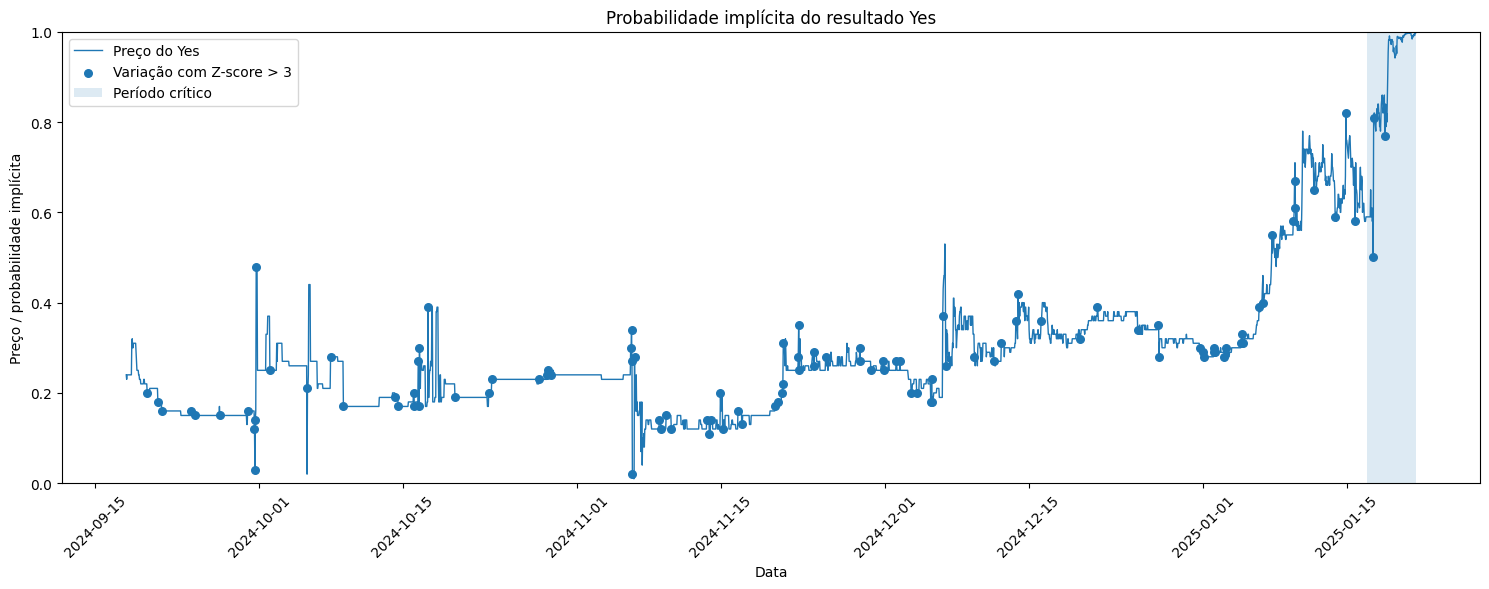

In [12]:
preco_atipico = preco_horario[
    preco_horario["z_score_price"] > 3
]

plt.figure(figsize=(15, 6))

plt.plot(
    preco_horario["trade_hour"],
    preco_horario["yes_price"],
    linewidth=1,
    label="Preço do Yes"
)

plt.scatter(
    preco_atipico["trade_hour"],
    preco_atipico["yes_price"],
    s=30,
    label="Variação com Z-score > 3",
    zorder=3
)

plt.axvspan(
    pd.Timestamp("2025-01-17", tz="UTC"),
    pd.Timestamp("2025-01-21 17:00:00", tz="UTC"),
    alpha=0.15,
    label="Período crítico"
)

plt.title("Probabilidade implícita do resultado Yes")
plt.xlabel("Data")
plt.ylabel("Preço / probabilidade implícita")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

In [13]:
preco_horario.nlargest(
    10,
    "z_score_price"
)[[
    "trade_hour",
    "previous_price",
    "yes_price",
    "price_change",
    "z_score_price"
]]

,trade_hour,previous_price,yes_price,price_change,z_score_price
1742,2024-11-29 15:00:00+00:00,0.27,0.250000,0.020000,7083.617469
508,2024-10-09 05:00:00+00:00,0.27,0.170001,0.099999,48.785181
1910,2024-12-06 15:00:00+00:00,0.19,0.370000,0.180000,34.955712
2416,2024-12-27 17:00:00+00:00,0.35,0.280000,0.070000,34.088732
478,2024-10-07 23:00:00+00:00,0.21,0.280000,0.070000,34.088732
1180,2024-11-06 05:00:00+00:00,0.24,0.300000,0.060000,29.189753
74,2024-09-21 03:00:00+00:00,0.21,0.180000,0.030000,14.492814
1572,2024-11-22 13:00:00+00:00,0.25,0.280000,0.030000,14.492814
769,2024-10-20 02:00:00+00:00,0.22,0.190000,0.030000,14.492814
2081,2024-12-13 18:00:00+00:00,0.31,0.360000,0.050000,14.430307


A série do token Yes permite acompanhar diretamente a evolução da probabilidade implícita do evento. O Z-score das variações horárias destaca momentos em que a mudança de preço é significativamente maior do que o comportamento das 24 horas anteriores.

Assim como no volume, esse indicador será tratado como candidato a sinal. Na etapa seguinte, os resultados de volume e preço serão avaliados para definir os critérios utilizados nos dois alertas finais.

### 3.3 Avaliação dos sinais candidatos

Após o cálculo dos indicadores de volume e preço, foram comparados diferentes limiares de Z-score e critérios mínimos de magnitude. O objetivo foi reduzir sinais pouco relevantes sem perder ocorrências concentradas no período crítico de 17 a 21 de janeiro.


In [14]:
limiares = [2, 3, 4]

avaliacao_volume = []

for limite in limiares:
    sinais = volume_horario[
        volume_horario["z_score_volume"] > limite
    ]

    periodo_critico = sinais[
        (sinais["trade_hour"] >= "2025-01-17") &
        (sinais["trade_hour"] <= "2025-01-21 23:59:59+00:00")
    ]

    avaliacao_volume.append({
        "z_score": limite,
        "total_sinais": len(sinais),
        "sinais_periodo_critico": len(periodo_critico)
    })

avaliacao_volume = pd.DataFrame(avaliacao_volume)
avaliacao_volume

,z_score,total_sinais,sinais_periodo_critico
0,2,200,21
1,3,152,11
2,4,120,5


In [15]:
avaliacao_preco = []

for limite in limiares:
    sinais = preco_horario[
        preco_horario["z_score_price"] > limite
    ]

    periodo_critico = sinais[
        (sinais["trade_hour"] >= "2025-01-17") &
        (sinais["trade_hour"] <= "2025-01-21 23:59:59+00:00")
    ]

    avaliacao_preco.append({
        "z_score": limite,
        "total_sinais": len(sinais),
        "sinais_periodo_critico": len(periodo_critico)
    })

avaliacao_preco = pd.DataFrame(avaliacao_preco)
avaliacao_preco

,z_score,total_sinais,sinais_periodo_critico
0,2,176,6
1,3,106,3
2,4,71,3


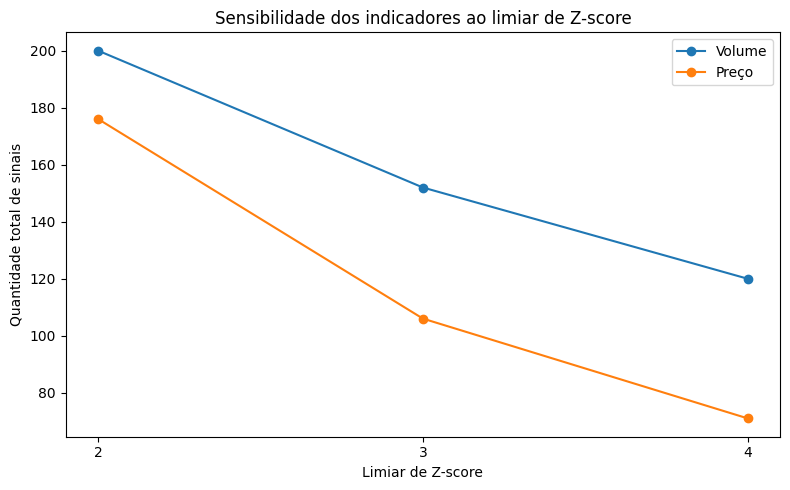

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao_volume["z_score"],
    avaliacao_volume["total_sinais"],
    marker="o",
    label="Volume"
)

plt.plot(
    avaliacao_preco["z_score"],
    avaliacao_preco["total_sinais"],
    marker="o",
    label="Preço"
)

plt.xlabel("Limiar de Z-score")
plt.ylabel("Quantidade total de sinais")
plt.title("Sensibilidade dos indicadores ao limiar de Z-score")
plt.xticks(limiares)
plt.legend()
plt.tight_layout()

plt.show()

Para o volume, `Z > 3` preserva mais ocorrências no período crítico do que `Z > 4`. Para o preço, a passagem de `Z > 3` para `Z > 4` reduz a quantidade total de sinais sem diminuir o número de ocorrências identificadas no período crítico. Por isso, `Z > 3` e `Z > 4` foram adotados como candidatos iniciais para volume e preço, respectivamente.


In [17]:
limiares_volume = [10000, 50000, 100000]

avaliacao_magnitude_volume = []

for volume_minimo in limiares_volume:
    sinais = volume_horario[
        (volume_horario["z_score_volume"] > 3) &
        (volume_horario["usd_volume"] > volume_minimo)
    ]

    periodo_critico = sinais[
        (sinais["trade_hour"] >= "2025-01-17") &
        (sinais["trade_hour"] <= "2025-01-21 23:59:59+00:00")
    ]

    avaliacao_magnitude_volume.append({
        "volume_minimo": volume_minimo,
        "total_sinais": len(sinais),
        "sinais_periodo_critico": len(periodo_critico)
    })

avaliacao_magnitude_volume = pd.DataFrame(avaliacao_magnitude_volume)
avaliacao_magnitude_volume

,volume_minimo,total_sinais,sinais_periodo_critico
0,10000,27,11
1,50000,12,11
2,100000,11,11


In [18]:
limiares_variacao = [0.03, 0.05, 0.10]

avaliacao_magnitude_preco = []

for variacao_minima in limiares_variacao:
    sinais = preco_horario[
        (preco_horario["z_score_price"] > 4) &
        (preco_horario["price_change"] >= variacao_minima)
    ]

    periodo_critico = sinais[
        (sinais["trade_hour"] >= "2025-01-17") &
        (sinais["trade_hour"] <= "2025-01-21 23:59:59+00:00")
    ]

    avaliacao_magnitude_preco.append({
        "variacao_minima": variacao_minima,
        "total_sinais": len(sinais),
        "sinais_periodo_critico": len(periodo_critico)
    })

avaliacao_magnitude_preco = pd.DataFrame(avaliacao_magnitude_preco)
avaliacao_magnitude_preco

,variacao_minima,total_sinais,sinais_periodo_critico
0,0.03,48,3
1,0.05,32,3
2,0.10,12,1


Os testes de magnitude tornaram os dois indicadores mais seletivos. Para o volume, a combinação `Z > 3` com volume superior a **US$ 100 mil** reduziu os sinais a 11 ocorrências, todas concentradas no período crítico.

Para o preço, a combinação `Z > 4` com variação absoluta de pelo menos **0,05** reduziu os sinais de 71 para 32 sem eliminar nenhuma das três ocorrências identificadas no período crítico.

Assim, esses critérios foram selecionados para a construção dos dois alertas finais.


## 4. Dois Alertas Finais

Com base nas análises desenvolvidas na seção anterior, foram considerados dois alertas: um voltado à identificação de volumes anormalmente elevados e outro à detecção de movimentações atípicas na probabilidade implícita do mercado. As regras utilizam o comportamento recente do próprio mercado como referência e retornam somente os registros que atendem aos critérios definidos.


### 4.1 Alerta de volume anormal

O primeiro alerta identifica horas em que o volume negociado apresenta simultaneamente um desvio elevado em relação às 24 horas anteriores e magnitude absoluta relevante. A partir da avaliação realizada na Seção 3, foram adotados os critérios `Z-score > 3` e volume horário superior a **US$ 100 mil**.


```sql
WITH horas AS (
    SELECT
        trade_hour
    FROM UNNEST(
        GENERATE_TIMESTAMP_ARRAY(
            TIMESTAMP('2024-09-18 01:00:00+00'),
            TIMESTAMP('2025-01-21 17:00:00+00'),
            INTERVAL 1 HOUR
        )
    ) AS trade_hour
),

volume_por_hora AS (
    SELECT
        TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,
        COUNT(*) AS trade_count,
        SUM(usd_amount) AS usd_volume
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE
        market_id = '507276'
        AND DATE(trade_timestamp)
            BETWEEN '2024-09-18' AND '2025-01-21'
    GROUP BY
        trade_hour
),

serie_horaria AS (
    SELECT
        h.trade_hour,
        COALESCE(v.trade_count, 0) AS trade_count,
        COALESCE(v.usd_volume, 0) AS usd_volume
    FROM horas AS h
    LEFT JOIN volume_por_hora AS v
        ON h.trade_hour = v.trade_hour
),

estatisticas_volume AS (
    SELECT
        trade_hour,
        trade_count,
        usd_volume,

        COUNT(*) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS horas_historico,

        AVG(usd_volume) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS avg_volume_24h,

        STDDEV_SAMP(usd_volume) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS stddev_volume_24h

    FROM serie_horaria
),

volume_com_zscore AS (
    SELECT
        trade_hour,
        trade_count,
        usd_volume,
        avg_volume_24h,
        stddev_volume_24h,

        CASE
            WHEN horas_historico = 24
                 AND stddev_volume_24h > 0
            THEN SAFE_DIVIDE(
                usd_volume - avg_volume_24h,
                stddev_volume_24h
            )
        END AS z_score_volume

    FROM estatisticas_volume
)

SELECT
    '507276' AS market_id,
    trade_hour AS data_referencia,
    trade_count,
    usd_volume AS volume_atual,
    avg_volume_24h AS volume_medio_24h,
    stddev_volume_24h AS desvio_volume_24h,
    z_score_volume,
    'VOLUME_ANORMAL' AS tipo_alerta
FROM volume_com_zscore
WHERE
    z_score_volume > 3
    AND usd_volume > 100000
ORDER BY
    trade_hour;
```

In [19]:
alerta_volume = pd.read_csv(
    "dados/07_alerta_volume.csv"
)

alerta_volume

,market_id,data_referencia,trade_count,volume_atual,volume_medio_24h,desvio_volume_24h,z_score_volume,tipo_alerta
0,507276,2025-01-17 15:00:00.000000 UTC,830,212072.34,4850.969167,5655.823624,36.638584,VOLUME_ANORMAL
1,507276,2025-01-19 01:00:00.000000 UTC,364,146575.36,28454.201250,24467.023922,4.827770,VOLUME_ANORMAL
2,507276,2025-01-19 02:00:00.000000 UTC,427,176335.00,32734.680000,34290.724599,4.187731,VOLUME_ANORMAL
3,507276,2025-01-19 03:00:00.000000 UTC,465,565845.41,39394.486250,44885.187105,11.728834,VOLUME_ANORMAL
4,507276,2025-01-19 06:00:00.000000 UTC,190,564688.20,83723.724167,131582.365205,3.655235,VOLUME_ANORMAL
5,507276,2025-01-19 16:00:00.000000 UTC,1087,1098528.50,244785.264167,218313.879792,3.910623,VOLUME_ANORMAL
6,507276,2025-01-19 22:00:00.000000 UTC,481,1313164.47,384828.020833,294772.901663,3.149328,VOLUME_ANORMAL
7,507276,2025-01-20 04:00:00.000000 UTC,754,1558672.48,533296.194167,335357.410949,3.057563,VOLUME_ANORMAL
8,507276,2025-01-20 11:00:00.000000 UTC,608,2117874.34,612006.909583,381164.720697,3.950700,VOLUME_ANORMAL
9,507276,2025-01-20 12:00:00.000000 UTC,385,2957621.60,689594.761250,481746.938197,4.707922,VOLUME_ANORMAL


### 4.2 Alerta de movimentação atípica de preço

O segundo alerta identifica alterações excepcionalmente intensas na probabilidade implícita do resultado `Yes`. A regra combina o desvio estatístico da variação horária em relação às 24 horas anteriores com uma magnitude mínima de mudança.

Com base na avaliação da Seção 3, o alerta é acionado apenas quando o Z-score da variação é superior a 4 e a mudança absoluta de preço é de pelo menos **0,05**, equivalente a 5 pontos percentuais de probabilidade implícita.



```sql
WITH horas AS (
    SELECT
        trade_hour
    FROM UNNEST(
        GENERATE_TIMESTAMP_ARRAY(
            TIMESTAMP('2024-09-18 01:00:00+00'),
            TIMESTAMP('2025-01-21 17:00:00+00'),
            INTERVAL 1 HOUR
        )
    ) AS trade_hour
),

preco_por_hora AS (
    SELECT
        TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS trade_hour,

        ARRAY_AGG(
            price
            ORDER BY trade_timestamp DESC
            LIMIT 1
        )[OFFSET(0)] AS close_price

    FROM `even-continuity-441808-j0.polymarket_optimized.trades`

    WHERE
        market_id = '507276'
        AND asset_id =
            '24635636911615866092589652362670811323984202357282728474473612545495782013438'
        AND DATE(trade_timestamp)
            BETWEEN '2024-09-18' AND '2025-01-21'

    GROUP BY
        trade_hour
),

serie_preco AS (
    SELECT
        h.trade_hour,

        LAST_VALUE(
            p.close_price IGNORE NULLS
        ) OVER (
            ORDER BY h.trade_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS yes_price

    FROM horas AS h

    LEFT JOIN preco_por_hora AS p
        ON h.trade_hour = p.trade_hour
),

preco_anterior AS (
    SELECT
        trade_hour,
        yes_price,

        LAG(yes_price) OVER (
            ORDER BY trade_hour
        ) AS previous_price

    FROM serie_preco
),

variacoes AS (
    SELECT
        trade_hour,
        yes_price,
        previous_price,

        ABS(
            yes_price - previous_price
        ) AS price_change

    FROM preco_anterior
),

estatisticas_preco AS (
    SELECT
        trade_hour,
        yes_price,
        previous_price,
        price_change,

        COUNT(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS horas_historico,

        AVG(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS avg_change_24h,

        STDDEV_SAMP(price_change) OVER (
            ORDER BY trade_hour
            ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
        ) AS stddev_change_24h

    FROM variacoes
),

preco_com_zscore AS (
    SELECT
        trade_hour,
        yes_price,
        previous_price,
        price_change,
        avg_change_24h,
        stddev_change_24h,

        CASE
            WHEN
                horas_historico = 24
                AND stddev_change_24h > 0
            THEN SAFE_DIVIDE(
                price_change - avg_change_24h,
                stddev_change_24h
            )
        END AS z_score_price

    FROM estatisticas_preco
)

SELECT
    '507276' AS market_id,
    trade_hour AS data_referencia,
    yes_price AS probabilidade_atual,
    previous_price AS probabilidade_anterior,
    price_change AS variacao_absoluta,
    avg_change_24h AS variacao_media_24h,
    stddev_change_24h AS desvio_variacao_24h,
    z_score_price,
    'MOVIMENTACAO_PRECO_ATIPICA' AS tipo_alerta

FROM preco_com_zscore

WHERE
    z_score_price > 4
    AND price_change >= 0.05

ORDER BY
    trade_hour;
```

In [20]:
alerta_preco = pd.read_csv(
    "dados/08_alerta_preco.csv"
)

alerta_preco.head()

,market_id,data_referencia,probabilidade_atual,probabilidade_anterior,variacao_absoluta,variacao_media_24h,desvio_variacao_24h,z_score_price,tipo_alerta
0,507276,2024-09-30 14:00:00.000000 UTC,0.030000,0.12,0.090000,0.003750,0.010555,8.171442,MOVIMENTACAO_PRECO_ATIPICA
1,507276,2024-09-30 15:00:00.000000 UTC,0.140000,0.03,0.110000,0.007500,0.020483,5.004101,MOVIMENTACAO_PRECO_ATIPICA
2,507276,2024-09-30 17:00:00.000000 UTC,0.479998,0.16,0.319998,0.012917,0.029114,10.547441,MOVIMENTACAO_PRECO_ATIPICA
3,507276,2024-10-02 01:00:00.000000 UTC,0.250000,0.37,0.120000,0.005000,0.017937,6.411297,MOVIMENTACAO_PRECO_ATIPICA
4,507276,2024-10-07 23:00:00.000000 UTC,0.280000,0.21,0.070000,0.000417,0.002041,34.088732,MOVIMENTACAO_PRECO_ATIPICA


A combinação dos dois critérios torna o alerta mais seletivo ao exigir que a movimentação seja simultaneamente incomum em relação ao comportamento recente e relevante em magnitude absoluta. Dessa forma, pequenas oscilações que produzem Z-scores elevados em períodos de baixa volatilidade são descartadas.

A query retorna apenas os registros que atendem aos critérios definidos, produzindo o conjunto final de sinais de movimentação atípica de preço.


## 5. Demonstração e avaliação dos alertas

### 5.1 Eventos externos de referência

Para avaliar os alertas, foram selecionados acontecimentos externos diretamente relacionados à possibilidade de proibição do TikTok nos Estados Unidos. Os horários foram registrados em UTC, mesma referência temporal utilizada nos dados do mercado.

| Data e hora (UTC) | Evento                                                                      |
| ----------------- | --------------------------------------------------------------------------- |
| 17/01/2025 15:10  | Divulgação da decisão da Suprema Corte que manteve a validade da lei        |
| 18/01/2025 17:41  | Donald Trump afirma que provavelmente concederia uma prorrogação de 90 dias |
| 19/01/2025 03:59  | TikTok deixa de funcionar para usuários nos Estados Unidos                  |
| 19/01/2025 17:36  | TikTok anuncia o início da restauração do serviço                           |

A data da decisão judicial é confirmada pela Suprema Corte, enquanto o horário adotado corresponde à primeira publicação identificada sobre o resultado. Os demais horários correspondem às publicações que registraram os acontecimentos em tempo próximo à sua ocorrência.


In [21]:
eventos_externos = pd.DataFrame({
    "data_hora_evento": pd.to_datetime([
        "2025-01-17 15:10:00+00:00",
        "2025-01-18 17:41:00+00:00",
        "2025-01-19 03:35:00+00:00",
        "2025-01-19 17:36:00+00:00"
    ]),
    "evento": [
        "Suprema Corte mantém a validade da lei",
        "Trump sinaliza possível prorrogação de 90 dias",
        "TikTok fica indisponível nos Estados Unidos",
        "TikTok anuncia o início da restauração do serviço"
    ],
    "fonte": [
        "Suprema Corte dos EUA e NPR",
        "Reuters",
        "NPR",
        "Reuters"
    ],
    "url_fonte": [
        "https://www.supremecourt.gov/opinions/slipopinion/24",
        "https://www.yahoo.com/news/trump-most-likely-tiktok-90-174105455.html",
        "https://www.npr.org/2025/01/18/nx-s1-5266146/tiktok-offline-supreme-court-ban",
        "https://www.investing.com/news/world-news/tiktok-says-it-is-restoring-service-in-us-3820119"
    ]
})

eventos_externos

,data_hora_evento,evento,fonte,url_fonte
0,2025-01-17 15:10:00+00:00,Suprema Corte mantém a validade da lei,Suprema Corte dos EUA e NPR,https://www.supremecourt.gov/opinions/slipopin...
1,2025-01-18 17:41:00+00:00,Trump sinaliza possível prorrogação de 90 dias,Reuters,https://www.yahoo.com/news/trump-most-likely-t...
2,2025-01-19 03:35:00+00:00,TikTok fica indisponível nos Estados Unidos,NPR,https://www.npr.org/2025/01/18/nx-s1-5266146/t...
3,2025-01-19 17:36:00+00:00,TikTok anuncia o início da restauração do serviço,Reuters,https://www.investing.com/news/world-news/tikt...


Um alerta foi considerado associado a um evento externo quando ocorreu no intervalo de até seis horas antes ou depois do acontecimento. Essa janela permite considerar o tempo de circulação da informação e de reação dos participantes do mercado.

In [22]:
janela_evento = pd.Timedelta(hours=6)

alerta_volume["data_referencia"] = pd.to_datetime(
    alerta_volume["data_referencia"],
    utc=True
)

alerta_preco["data_referencia"] = pd.to_datetime(
    alerta_preco["data_referencia"],
    utc=True
)

A seguir, os eventos foram associados aos alertas estabeleidos na seção anterior:

In [23]:
def associar_evento(data_alerta):
    diferencas = (
        eventos_externos["data_hora_evento"] - data_alerta
    ).abs()

    indice_mais_proximo = diferencas.idxmin()
    menor_diferenca = diferencas.loc[indice_mais_proximo]

    if menor_diferenca <= janela_evento:
        return pd.Series({
            "associado_evento": True,
            "evento_associado": eventos_externos.loc[
                indice_mais_proximo,
                "evento"
            ],
            "distancia_horas": (
                menor_diferenca.total_seconds() / 3600
            )
        })

    return pd.Series({
        "associado_evento": False,
        "evento_associado": None,
        "distancia_horas": None
    })

In [24]:
alerta_volume = pd.concat(
    [
        alerta_volume,
        alerta_volume["data_referencia"].apply(
            associar_evento
        )
    ],
    axis=1
)

alerta_preco = pd.concat(
    [
        alerta_preco,
        alerta_preco["data_referencia"].apply(
            associar_evento
        )
    ],
    axis=1
)

## 5.2 Taxa de correspondência dos alertas

In [25]:
total_volume = len(alerta_volume)
associados_volume = alerta_volume["associado_evento"].sum()
taxa_volume = associados_volume / total_volume

total_preco = len(alerta_preco)
associados_preco = alerta_preco["associado_evento"].sum()
taxa_preco = associados_preco / total_preco

print(f"Alerta de volume: {associados_volume}/{total_volume}")
print(f"Taxa de correspondência: {taxa_volume:.2%}")

print()

print(f"Alerta de preço: {associados_preco}/{total_preco}")
print(f"Taxa de correspondência: {taxa_preco:.2%}")

Alerta de volume: 7/11
Taxa de correspondência: 63.64%

Alerta de preço: 3/32
Taxa de correspondência: 9.38%


O alerta de volume apresentou correspondência com eventos externos em 7 dos 11 disparos, resultando em uma taxa de 63,64%. Esse resultado indica que aumentos anormais de volume estiveram frequentemente associados a momentos de divulgação de notícias relevantes, tornando esse alerta mais adequado para identificar reações do mercado a acontecimentos externos.

O alerta de preço apresentou correspondência em 3 dos 32 disparos, com taxa de 9,38%. Isso sugere que as variações bruscas de preço foram menos específicas para os eventos externos selecionados. O indicador pode ter capturado também revisões de expectativa, movimentos especulativos, baixa liquidez ou outras oscilações internas do mercado.

Assim, o alerta de volume demonstrou maior utilidade para detectar períodos de reação a notícias, enquanto o alerta de preço funcionou como um indicador mais amplo de instabilidade e mudança nas expectativas dos participantes.

### 5.3 Visualização do alerta de volume

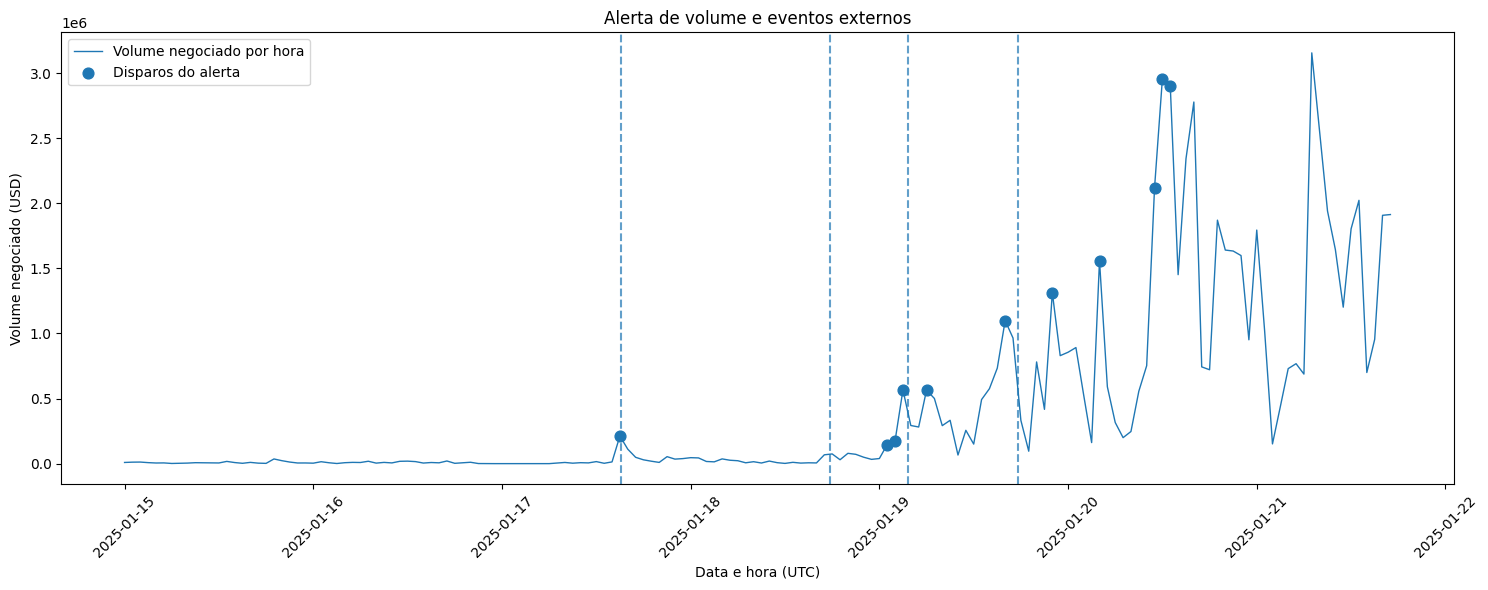

In [26]:

volume_horario["trade_hour"] = pd.to_datetime(
    volume_horario["trade_hour"],
    utc=True
)

alerta_volume["data_referencia"] = pd.to_datetime(
    alerta_volume["data_referencia"],
    utc=True
)

eventos_externos["data_hora_evento"] = pd.to_datetime(
    eventos_externos["data_hora_evento"],
    utc=True
)

inicio_visualizacao = pd.Timestamp(
    "2025-01-15 00:00:00",
    tz="UTC"
)

fim_visualizacao = pd.Timestamp(
    "2025-01-21 18:00:00",
    tz="UTC"
)

volume_periodo = volume_horario[
    volume_horario["trade_hour"].between(
        inicio_visualizacao,
        fim_visualizacao
    )
]

alertas_periodo = alerta_volume[
    alerta_volume["data_referencia"].between(
        inicio_visualizacao,
        fim_visualizacao
    )
]

eventos_periodo = eventos_externos[
    eventos_externos["data_hora_evento"].between(
        inicio_visualizacao,
        fim_visualizacao
    )
]

plt.figure(figsize=(15, 6))

plt.plot(
    volume_periodo["trade_hour"],
    volume_periodo["usd_volume"],
    linewidth=1,
    label="Volume negociado por hora"
)

plt.scatter(
    alertas_periodo["data_referencia"],
    alertas_periodo["volume_atual"],
    s=60,
    zorder=3,
    label="Disparos do alerta"
)

for _, evento in eventos_periodo.iterrows():
    plt.axvline(
        evento["data_hora_evento"],
        linestyle="--",
        alpha=0.7
    )

plt.title("Alerta de volume e eventos externos")
plt.xlabel("Data e hora (UTC)")
plt.ylabel("Volume negociado (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

### 5.4 Visualização do alerta de preço

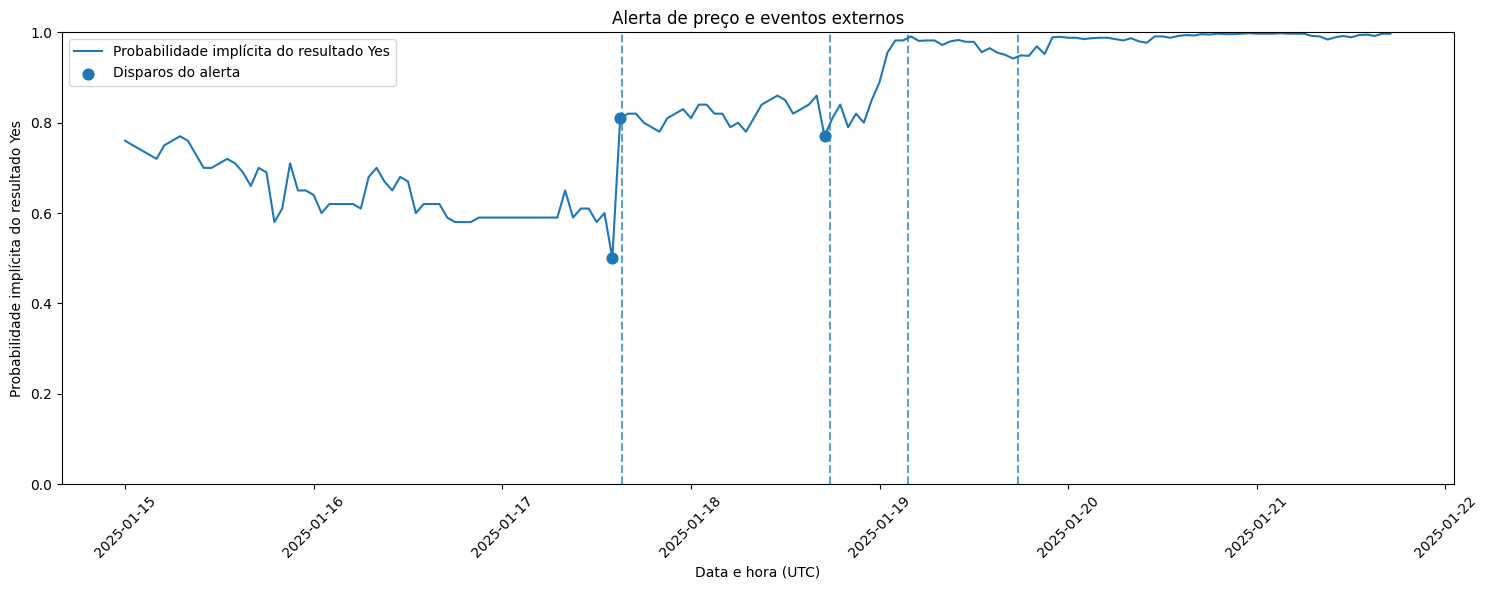

In [27]:
preco_horario["trade_hour"] = pd.to_datetime(
    preco_horario["trade_hour"],
    utc=True
)

alerta_preco["data_referencia"] = pd.to_datetime(
    alerta_preco["data_referencia"],
    utc=True
)

preco_periodo = preco_horario[
    preco_horario["trade_hour"].between(
        inicio_visualizacao,
        fim_visualizacao
    )
]

alertas_preco_periodo = alerta_preco[
    alerta_preco["data_referencia"].between(
        inicio_visualizacao,
        fim_visualizacao
    )
]

plt.figure(figsize=(15, 6))

plt.plot(
    preco_periodo["trade_hour"],
    preco_periodo["yes_price"],
    linewidth=1.5,
    label="Probabilidade implícita do resultado Yes"
)

plt.scatter(
    alertas_preco_periodo["data_referencia"],
    alertas_preco_periodo["probabilidade_atual"],
    s=60,
    zorder=3,
    label="Disparos do alerta"
)

for _, evento in eventos_periodo.iterrows():
    plt.axvline(
        evento["data_hora_evento"],
        linestyle="--",
        alpha=0.7
    )

plt.title("Alerta de preço e eventos externos")
plt.xlabel("Data e hora (UTC)")
plt.ylabel("Probabilidade implícita do resultado Yes")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()